In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [5]:
dataset_path = Path("customer_churn_data.csv")
if not dataset_path.exists():
    dataset_path = Path("Customer CA") / "customer_churn_data.csv"

df = pd.read_csv(dataset_path)

In [6]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [8]:
df.isna().sum().sum()

np.int64(297)

In [9]:
df['InternetService'] = df['InternetService'].fillna("")

In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
df.tail()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,,4465.56,No,Yes
999,1000,50,Male,1,56.67,Month-to-Month,,56.67,No,Yes


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [14]:
numeric_columns_data = df.select_dtypes(include = ["number"])

In [15]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


<Axes: ylabel='count'>

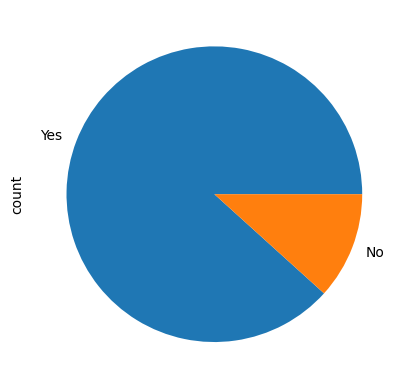

In [16]:
df["Churn"].value_counts().plot(kind ="pie")

In [17]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [ ]:
y = df["Churn"].map({"Yes": 1, "No": 0})
x = df.drop(columns=["CustomerID", "Churn"])

numeric_features = ["Age", "Tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = ["Gender", "ContractType", "InternetService", "TechSupport"]


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


In [ ]:
results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(x_train, y_train)
    predictions = pipeline.predict(x_test)
    accuracy = accuracy_score(y_test, predictions)
    results.append({"Model": name, "Accuracy": accuracy})
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
y_pred = best_model.predict(x_test)

print("Best model:", best_model_name)
print("Accuracy score on model is {:.2f}".format(accuracy_score(y_test, y_pred)))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
new_customer = pd.DataFrame([{
    "Age": 40,
    "Gender": "Male",
    "Tenure": 20,
    "MonthlyCharges": 80,
    "ContractType": "Month-to-Month",
    "InternetService": "Fiber Optic",
    "TotalCharges": 1600,
    "TechSupport": "No"
}])

prediction = best_model.predict(new_customer)[0]
"Churn" if prediction == 1 else "No Churn"


In [ ]:
import joblib

model_path = dataset_path.parent / "churn_model.pkl"
joblib.dump(best_model, model_path)
